<a href="https://colab.research.google.com/github/Sweper27/244107020175-Mesin-Learning/blob/main/Tugas_Klasterisasi/K_Means_Manhattan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K-Means Manhattan

In [3]:
import time
import tracemalloc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# BAGIAN A: LOAD DATA & PREPROCESSING

# Load dataset (separator TAB)
df = pd.read_csv('marketing_campaign.csv', sep='\t')

# Pilih fitur numerik yang relevan
kolom_fitur = [
    'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency',
    'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
    'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases',
    'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
    'NumWebVisitsMonth'
]
kolom_ada = [k for k in kolom_fitur if k in df.columns]
df_fitur  = df[kolom_ada].dropna()

# Encoding jika ada kolom teks
kolom_teks = df_fitur.select_dtypes(include='object').columns.tolist()
if kolom_teks:
    df_fitur = pd.get_dummies(df_fitur, columns=kolom_teks, drop_first=True)

# Standardisasi
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df_fitur)

# L2 Normalization untuk Cosine (tidak dipakai di sini, tapi disiapkan)
from sklearn.preprocessing import Normalizer
X_l2 = Normalizer(norm='l2').fit_transform(X_scaled)

print(f"Data siap | Shape: {X_scaled.shape} | Baris: {len(df_fitur)}")

Data siap | Shape: (2216, 16) | Baris: 2216


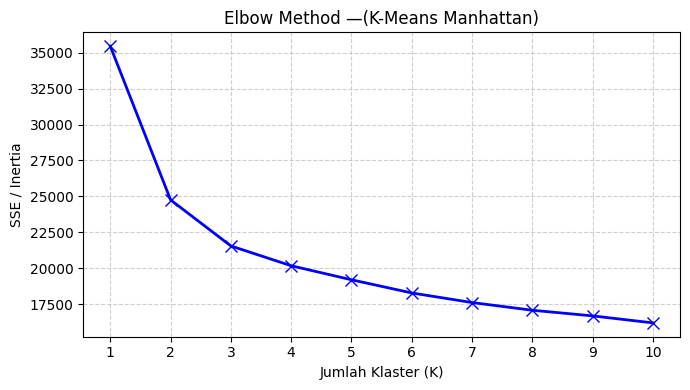

In [4]:
# BAGIAN B: ELBOW METHOD (untuk menentukan K terbaik)

K_range = range(1, 11)
sse     = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    sse.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(K_range), sse, 'bx-', linewidth=2, markersize=8)
plt.xlabel('Jumlah Klaster (K)')
plt.ylabel('SSE / Inertia')
plt.title('Elbow Method —(K-Means Manhattan)')
plt.xticks(list(K_range))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('a1_elbow.png')
plt.show()

K_TERBAIK = 4  # Ganti sesuai hasil elbow

In [5]:
# Install scikit-learn-extra untuk mendapatkan akses ke KMedoids
!pip install scikit-learn-extra

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 10.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-learn-extra: filename=scikit_learn_extra-0.3.0-cp313-cp313-linux_x86_64.whl size=2154569 sha256=64fc089be8e703be6f35b1ae6010eee02e3a029b8dd406f54f0f9f99d21e3e74
  Stored in directory: /root/.cache/pip/wheels/17/4b/b8/6b6711681d0981b110c9cc91ad6d1ebd88adf1547e1da301fc
Successfully built scikit-learn-extra


In [6]:
from sklearn_extra.cluster import KMedoids
import time
import tracemalloc

print("\n" + "="*52)
print("  K-MEDOIDS — METRIK BENAR: MANHATTAN")
print("="*52)

tracemalloc.start()
t_mulai = time.time()

# KMedoids mendukung parameter 'metric' secara langsung
kmedoids_manhattan = KMedoids(n_clusters=K_TERBAIK, metric='manhattan', random_state=42)
lbl_kmedoids = kmedoids_manhattan.fit_predict(X_scaled)

t_selesai = time.time()
_, mem_puncak = tracemalloc.get_traced_memory()
tracemalloc.stop()

# Hitung Silhouette Score yang sesuai menggunakan metrik manhattan
sil_kmedoids = silhouette_score(X_scaled, lbl_kmedoids, metric='manhattan')

print(f"  Jumlah Klaster    : {K_TERBAIK}")
print(f"  Waktu Eksekusi    : {t_selesai - t_mulai:.4f} detik")
print(f"  Memori Puncak     : {mem_puncak/1024:.2f} KB ({mem_puncak/1024**2:.4f} MB)")
print(f"  Silhouette Score  : {sil_kmedoids:.4f}")
print("="*52)


  K-MEDOIDS — METRIK BENAR: MANHATTAN
  Jumlah Klaster    : 4
  Waktu Eksekusi    : 0.1624 detik
  Memori Puncak     : 43980.12 KB (42.9493 MB)
  Silhouette Score  : 0.1842


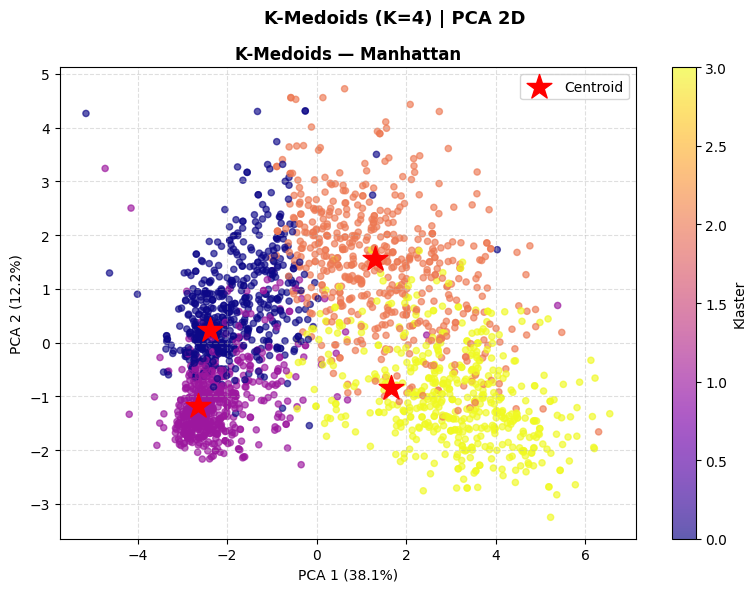

Visualisasi disimpan: 'a1_kmedoids_plot.png'

  RINGKASAN
  Metrik        Klaster   Silhouette
  ------------------------------------
  Manhattan           4       0.1842


In [7]:
# BAGIAN E: VISUALISASI PCA (Manhattan)

pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
v1, v2 = pca.explained_variance_ratio_ * 100

fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))
fig.suptitle(f'K-Medoids (K={K_TERBAIK}) | PCA 2D', fontsize=13, fontweight='bold')

# Plot Manhattan
sc2 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=lbl_kmedoids,
                  cmap='plasma', s=20, alpha=0.65)
cen2 = pca.transform(kmedoids_manhattan.cluster_centers_)
ax1.scatter(cen2[:, 0], cen2[:, 1], c='red', marker='*', s=350, zorder=5, label='Centroid')
ax1.set_title('K-Medoids — Manhattan', fontweight='bold')
ax1.set_xlabel(f'PCA 1 ({v1:.1f}%)')
ax1.set_ylabel(f'PCA 2 ({v2:.1f}%)')
ax1.legend(); ax1.grid(True, linestyle='--', alpha=0.4)
plt.colorbar(sc2, ax=ax1, label='Klaster')

plt.tight_layout()
plt.savefig('a1_kmedoids_plot.png', dpi=150)
plt.show()
print("Visualisasi disimpan: 'a1_kmedoids_plot.png'")

# RINGKASAN
print("\n" + "="*52)
print("  RINGKASAN")
print("="*52)
print(f"  {'Metrik':<12} {'Klaster':>8} {'Silhouette':>12}")
print("  " + "-"*36)
print(f"  {'Manhattan':<12} {K_TERBAIK:>8} {sil_kmedoids:>12.4f}")
print("="*52)